In [ ]:
# This script uses class definition to store, access and compute GP Observables in an organized manner

import GPKoopman as gpk
import torch
import numpy as np
import matplotlib.pyplot as plt
import math
import datetime

if not torch.cuda.is_available():
    print('Cuda not available')

Imported PyTorch version: 2.5.1+cu124
Imported NumPy version: 2.2.1
True
NVIDIA GeForce RTX 3060 Laptop GPU


### Cost Function Definition

In [2]:
# Multi-Trajectory Cost Function Definition

def get_cost_grid(Z, X, Xplus, Xtrain, manager, nT=1, lambda1=1.0, lambda2=1.0, lambda3=1.0):
    """
    Computes the cost function as defined in the Word doc, with different GP Kernel hyperparameters for
    each observable.

    Args:
        Z: Tensor of shape (r**n, p), decision variable, required grad
        X: Tensor of shape (n, nT*N), dataset of N steps from all trajectories
        Xall: Tensor of shape (n, nT*(N+1)), complete training dataset
        Xtrain: Tensor of shape (n, r**n), flattened set of gridpoints for training GPOs
        manager: Object of class GPObservablesManager (manager for all Gaussian Process based Observable functions)
        nT: float, number of trajectories in training dataset
        lambda1: float, Weighting for prediction error minimization term
        lambda2: float, Weightining for Reconstruction Error penalty term
    """
    
    N = (X.shape[1])//nT    # Number of time steps in each trajectory
    p = Z.shape[1]          # Number of Observables
    l = Z.shape[0]//nT      # Decision Horizon
    n = X.shape[0]          # Dimensionality of original system

    for i in range(p):
        manager.train_observable(i, Xtrain, Z[:,i])

    # For current definition of GPOs
    # Training: Xtrain = dimensions x samples
    # Training: Ytrain = samples x (dimensions=1)
    # Prediction: Xquery = dimensions x num-query = Input
    # Prediction: Yquery = num-query x (dimensions=1) = Output

    # Lifting X and Xplus to higher dimension using trained GPOs
    M = torch.empty((p,N*nT))
    Mplus = torch.empty((p,N*nT))
    
    #Mall = torch.empty((p,(N+1)*nT))
    for i in range(p):
        M[i,:] = torch.transpose(manager.predict_mean(i, X), dim0=0, dim1=-1)
        Mplus[i,:] = torch.transpose(manager.predict_mean(i, Xplus), dim0=0, dim1=-1)
    
    # Compute C(z) and A(z)
    Mfull = torch.vstack((X, M))
    Mplusfull = torch.vstack((Xplus, Mplus))

    M_pinv = torch.linalg.pinv(Mfull)
    #Cz = X @ M_pinv
    Az = Mplusfull @ M_pinv
    C = torch.zeros((n,n+p))
    for i in range(n):
        C[i,i] = 1.
    
    # Cost term 1: Multi-Trajectory Prediction Error Minimization
    NormPEM = 0.0
    for j in range(nT):
        TrajPEM = 0.0
        for k in range(N - 1):
            pred_error = X[:, j*N + (k+1)] - C @ (torch.linalg.matrix_power(Az,k+1)) @ Mfull[:,j*N]   # multi-step at X (with Cz)
            TrajPEM += torch.norm(pred_error)
        NormPEM += TrajPEM
    
    # Linearity Enforcement
    NormLEP = 0.0
    for j in range(nT):
        TrajLEP = 0.0
        for k in range(l-1):
            Zk = torch.vstack([X[:, j*N + k].view(n,1), torch.transpose(Z[j*l + k, :], dim0=0, dim1=-1).view(p,1)])
            Zkplus = torch.vstack([X[:, j*N + k + 1].view(n,1), torch.transpose(Z[j*l + k + 1, :], dim0=0, dim1=-1).view(p,1)])
            lin_error = Zkplus - Az @ Zk
            TrajLEP += torch.norm(lin_error)
        NormLEP += TrajLEP
    
    # Weighted sum of terms
    cost = (lambda1 * NormPEM / (N * nT)) + (lambda2 * NormLEP / (l * nT))
    return cost

def get_cost_AC(Z, X, Xplus, Xtrain, manager, nT=1, lambda1=1.0, lambda2=1.0, lambda3=1.0):
    """
    Computes the cost function using a single differentiable GP forward pass per observable,
    merging the training and prediction steps by passing Z[:, i] directly to the forward method.
    
    Args:
        Z: Tensor of shape (r**n, p), decision variable (requires grad).
        X: Tensor of shape (n, nT*N), dataset of N steps per trajectory.
        Xplus: Tensor of shape (n, nT*N), time-shifted dataset.
        Xtrain: Tensor of shape (n, r**n), gridpoints for training.
        manager: GPObservablesManager.
        nT: Number of trajectories.
        lambda1: Weighting for NLPD.
        lambda2: Weighting for linearity enforcement.
        lambda3: Weighting for prediction error minimization.
    """
    N = X.shape[1] // nT    # Number of time steps per trajectory
    p = Z.shape[1]          # Number of observables
    l = Z.shape[0] // nT    # Decision horizon
    n = X.shape[0]          # State dimension

    # For each observable, call forward once on the full dataset X (and Xplus)
    M = torch.empty((p, N * nT), device=X.device)
    cov_all = [None] * p  # store full covariance matrices for X
    Mplus = torch.empty((p, N * nT), device=X.device)
    # cov_all_plus = [None] * p  # store full covariance matrices for Xplus

    for i in range(p):
        mean_i, cov_i = manager.observables[i].forward(X, Z[:, i])
        M[i, :] = torch.transpose(mean_i, 0, -1)
        cov_all[i] = cov_i

        mean_plus_i, _ = manager.observables[i].forward(Xplus, Z[:, i])
        Mplus[i, :] = torch.transpose(mean_plus_i, 0, -1)

    # Compute the pseudo-inverse lifting operator and the corresponding matrices Cz and Az.
    M_pinv = torch.linalg.pinv(M)
    Cz = X @ M_pinv
    Az = Mplus @ M_pinv

    # Cost Term 1: Negative Log Predictive Density (NLPD)
    NormNLPD = 0.0
    if not math.isclose(lambda1, 0):
        for j in range(nT):
            TrajNLPD = 0.0
            # Define the number of time steps for NLPD computation:
            num_steps = N - 2 - l
            vz_k = torch.empty((p, num_steps), device=X.device)
            for i in range(p):
                # For trajectory j, determine the indices for the NLPD slice.
                start = j * N + l + 1
                end = (j + 1) * N - 1  # end is exclusive
                # Extract the covariance for the slice from the precomputed full covariance.
                cov_sub = cov_all[i][start:end, start:end]
                # Get the diagonal elements (predictive variances) and clamp them.
                vz_k[i, :] = torch.clamp(torch.diag(cov_sub), min=1e-3)
            for k in range(num_steps):
                vx_next = torch.abs(torch.diag(Cz @ Az @ torch.diag(vz_k[:, k]) @ Az.T @ Cz.T).view(n, 1))
                error_term = ((X[:, j * N + l + 1 + k + 1] - Cz @ Az @ M[:, j * N + l + 1 + k]) ** 2) / vx_next
                log_term = torch.log(vx_next)
                TrajNLPD += torch.sum(error_term + log_term)
            NormNLPD += TrajNLPD

    # Cost Term 2: Linearity Enforcement
    NormLEP = 0.0
    if not math.isclose(lambda2, 0):
        for j in range(nT):
            TrajLEP = 0.0
            for k in range(l - 1):
                lin_error = torch.transpose(Z[j * l + k + 1, :], 0, -1) - Az @ torch.transpose(Z[j * l + k, :], 0, -1)
                TrajLEP += torch.norm(lin_error)
            NormLEP += TrajLEP

    # Cost Term 3: Prediction Error Minimization
    NormPEM = 0.0
    if not math.isclose(lambda3, 0):
        for j in range(nT):
            TrajPEM = 0.0
            for k in range(N - 1):
                pred_error = X[:, j * N + (k + 1)] - Cz @ (torch.linalg.matrix_power(Az, k + 1)) @ M[:, j * N]
                TrajPEM += torch.norm(pred_error)
            NormPEM += TrajPEM

    cost = (lambda1 * NormNLPD / ((N - l) * nT)) + (lambda2 * NormLEP / (l * nT)) + (lambda3 * NormPEM / (N * nT))
    return cost

def get_cost_varsep(Z, X, Xplus, manager, nT=1):
    """
    Calculate the 2-norm between next-step lifted state and linearly propagated lifted state
    Args:
        Z:
        X:
        Xplus:
        Xtrain:
        manager:
        nT:
    """
    N = X.shape[1] // nT    # Number of time steps per trajectory
    p = Z.shape[1]          # Number of observables
    l = Z.shape[0] // nT    # Decision horizon
    n = X.shape[0]          # State dimension

    # For each observable, call forward once on the full dataset X (and Xplus)
    M = torch.empty((p, N * nT), device=X.device)
    Mplus = torch.empty((p, N * nT), device=X.device)
    
    for i in range(p):
        mean_i, _ = manager.observables[i].forward(X, Z[:, i])
        M[i, :] = torch.transpose(mean_i, 0, -1)

        mean_plus_i, _ = manager.observables[i].forward(Xplus, Z[:, i])
        Mplus[i, :] = torch.transpose(mean_plus_i, 0, -1)
    
    # 2-norm
    mmt = M @ M.T
    try:
        L = torch.linalg.cholesky(mmt)
        invMMt = torch.cholesky_inverse(L)
    except RuntimeError:
        invMMt = torch.linalg.inv(mmt)

    Mpinv = M.T @ invMMt
    Mplus_bar = torch.vstack([Mplus, X])
    err = Mplus_bar - (Mplus_bar @ Mpinv @ M)
    err_norm = torch.norm(err)
    return err_norm


def get_cost_NLLP(Z, X, Xplus, Xtrain, manager, nT=1, lambda1=1.0, lambda2=1.0):
    """
    Computes the next-step negative log likelihood using single forward-pass
    """
    N = X.shape[1] // nT    # Number of time steps per trajectory
    p = Z.shape[1]          # Number of observables
    l = Z.shape[0] // nT    # Decision horizon
    n = X.shape[0]          # State dimension

    # For each observable, call forward once on the full dataset X (and Xplus)
    M = torch.empty((p, N * nT), device=X.device)
    cov_all = torch.empty((p, N * nT, N * nT), device=X.device)  # store full covariance matrices for X
    Mplus = torch.empty((p, N * nT), device=X.device)
    # cov_all_plus = [None] * p  # store full covariance matrices for Xplus

    for i in range(p):
        mean_i, cov_i = manager.observables[i].forward(X, Z[:, i])
        M[i, :] = torch.transpose(mean_i, 0, -1)
        cov_all[i, :, :] = cov_i

        mean_plus_i, _ = manager.observables[i].forward(Xplus, Z[:, i])
        Mplus[i, :] = torch.transpose(mean_plus_i, 0, -1)

    # Compute the pseudo-inverse lifting operator and the corresponding matrices Cz and Az.
    M_pinv = torch.linalg.pinv(M)
    Cz = X @ M_pinv
    Az = Mplus @ M_pinv

    TotalMLLp = 0.0
    if not math.isclose(lambda1, 0):
        for j in range(nT):
            TrajMLLp = 0.0
            for k in range(N-1):
                varmat = Cz @ Az @ (torch.diag(torch.clamp(cov_all[:, j*N + k, j*N + k], min=1e-4))) @ Az.T @ Cz.T
                varterm = -0.5 * torch.logdet(varmat)
                errvec = Xplus[:, k] - Cz @ Az @ M[:, k]
                meanterm = -0.5 * (errvec.T @ torch.linalg.pinv(varmat) @ errvec)
                TrajMLLp += varterm + meanterm

            TotalMLLp += TrajMLLp
        
    # Cost Term 2: Linearity Enforcement
    NormLEP = 0.0
    if not math.isclose(lambda2, 0):
        for j in range(nT):
            TrajLEP = 0.0
            for k in range(l - 1):
                lin_error = torch.transpose(Z[j * l + k + 1, :], 0, -1) - Az @ torch.transpose(Z[j * l + k, :], 0, -1)
                TrajLEP += torch.norm(lin_error)
            NormLEP += TrajLEP
    
    return lambda1 * TotalMLLp + lambda2 * NormLEP

# Execution Cells

## Data Loading

In [3]:
# Allowed system names -
# "Unforced Duffing" | "Unforced Duffing_right" | "van der Pol" | "Simple Pendulum"
# "Lorenz" | "Lotka Volterra" | "Piecewise Linear"

system_name = 'Simple Pendulum'
data = torch.load(f"Data/DataAuto_{system_name}.pt", weights_only=True)

SimData = data["trajectories"] # Shape: (num_trajectories, state_dim, num_steps)
ts = data["sample_time"]
num_trajectories = data["num_trajectories"]
N = data["num_steps"]

nTrain, nTest = math.floor(num_trajectories * 0.4), math.floor(num_trajectories * 0.2)

# Clip Training Data steps
SimData = SimData[:,:,:151]
N = 150

## Optimization Section

### Optimization Setup

In [6]:
SimData = SimData.float()
SimData = SimData.to(device='cuda:0')
# Original State Dim | Lifted State Dim | Learning Horizon | Resolution
n, p, l, r = SimData.shape[1], 10, 15, 10

Xall = torch.cat([SimData[j, :, :] for j in range(nTrain)], dim=1)      # Concatenated total matrix
X = torch.cat([SimData[j, :, 0:N] for j in range(nTrain)], dim=1)       # Concatenated Data matrix
Xplus = torch.cat([SimData[j, :, 1:] for j in range(nTrain)], dim=1)    # Time-shifted Data matrix

ICsetTrain = torch.cat([SimData[j, :, 0].view(n,1) for j in range(nTrain)], dim=1)    # Random IC set for training
ICsetTest = torch.cat([SimData[j, :, 0].view(n,1) for j in range(nTrain, nTrain + nTest)], dim=1)  # Random IC set for testing

# Options: 'Horizon' | 'Grid' | 'K-Means'
trainMethod = 'Horizon'

# Initialize GP training-grid and decision variables
if trainMethod == 'Horizon':
    Xtrain = torch.cat([X[:,j*N:j*N+l] for j in range(nTrain)],dim=1)
    #Z = torch.rand(Xtrain.shape[1], p, requires_grad=True)
    Z = torch.nn.Parameter(torch.rand(Xtrain.shape[1], p, device='cuda:0'))
    ObsManager = gpk.GPObservablesManager()
    for i in range(p):
        ObsManager.add_observable(index=i, d=n, ns=l*nTrain, kernel_types=['Gaussian'], combination='sum',noise=1e-4, m=500)
    for i in range(p):
        ObsManager.train_observable(i, Xtrain, Z[:, i])
    ObsManager.set_random_hyperparameters(scale=[1., 0.01, None])
    print('Observable Hyperparameters have been randomized:')
    ObsManager.print_parameters()

elif trainMethod == 'K-Means':
    Xtrain = torch.cat([X[:,j*N:j*N+l] for j in range(nTrain)],dim=1)
    Z = torch.nn.Parameter(torch.rand(Xtrain.shape[1], p, device='cuda:0'))
    ObsManager = gpk.GPObservablesManager()
    centroids = gpk.get_kmeans(X, num_centers=p)
    for i in range(p):
        ObsManager.add_observable(index=i, d=n, ns=l*nTrain, kernel_types=['ExplicitAttractor', 'Gaussian'], combination='product',noise=1e-4, m=500)
    
    mu_centroids = [centroids[:, i:i+1] for i in range(centroids.shape[1])]
    mu_centroids.extend(mu_centroids)
    ObsManager.set_parameters(mu_list=mu_centroids)
    for i in range(p):
        ObsManager.train_observable(i, Xtrain, Z[:, i])
    # ObsManager.set_random_hyperparameters(scale=[1., 0.1, None])
    hp1_val, hp2_val = 1.0, 0.5
    hp1_val = [torch.tensor([hp1_val], device='cuda:0') for _ in range(2*p)]
    hp2_val = [torch.tensor([hp2_val], device='cuda:0') for _ in range(p)]
    hp2_val.extend([torch.tensor([0.001], device='cuda:0') for _ in range(p)])
    ObsManager.set_parameters(hp1_list=hp1_val, hp2_list=hp2_val)
    # print('Observable Hyperparameters have been randomized:')
    ObsManager.print_parameters()

    for i in range(p):
        plt.plot(centroids[0,i].cpu(), centroids[1,i].cpu(), marker='o')
    plt.grid()
    plt.title('Centroids of K-Means Clusters'), plt.xlabel('X1'), plt.ylabel('X2')

elif trainMethod == 'Grid':
    # GPO Training Grid
    gridpoints0 = torch.linspace(-4., 4., steps=r)
    gridpoints1 = torch.linspace(-4., 4., steps=r)
    grid0, grid1 = torch.meshgrid(gridpoints0, gridpoints1, indexing='xy')
    Xtrain = torch.stack([torch.flatten(grid0), torch.flatten(grid1)])
    Z = torch.rand(r**n, p, requires_grad=True)
    ObsManager = gpk.GPObservablesManager()
    for i in range(p):
        ObsManager.add_observable(index=i, d=n, ns=r**n, kernel_types=['Gaussian', 'ExplicitAttractor'], combination='product', noise=1e-6)

else:
    raise ValueError(f'Unrecognized GP Training method {trainMethod}')


Observable Hyperparameters have been randomized:
Index | Kernel Types | Noise     | hp1       | hp2       | mu                    
---------------------------------------------------------------------------------
0     | Gaussian     | 1.000e-04 | 6.130e-01 | 9.877e-03 | [0.000e+00, 0.000e+00]
1     | Gaussian     | 1.000e-04 | 8.259e-01 | 7.296e-03 | [0.000e+00, 0.000e+00]
2     | Gaussian     | 1.000e-04 | 3.264e-01 | 3.148e-03 | [0.000e+00, 0.000e+00]
3     | Gaussian     | 1.000e-04 | 2.255e-01 | 3.584e-03 | [0.000e+00, 0.000e+00]
4     | Gaussian     | 1.000e-04 | 5.480e-01 | 2.663e-03 | [0.000e+00, 0.000e+00]
5     | Gaussian     | 1.000e-04 | 5.246e-01 | 3.273e-03 | [0.000e+00, 0.000e+00]
6     | Gaussian     | 1.000e-04 | 3.806e-01 | 2.197e-03 | [0.000e+00, 0.000e+00]
7     | Gaussian     | 1.000e-04 | 2.590e-01 | 7.428e-03 | [0.000e+00, 0.000e+00]
8     | Gaussian     | 1.000e-04 | 9.205e-01 | 9.666e-04 | [0.000e+00, 0.000e+00]
9     | Gaussian     | 1.000e-04 | 6.813e-01 | 3.

#### Optional Plotting

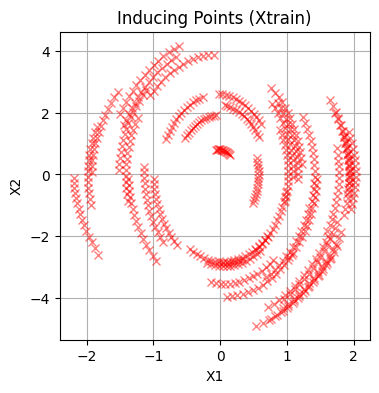

In [7]:
# Plot the Xtrain points in 2D space
if Xtrain.shape[0] >= 2:    # Optional Plotting in 2D space
    Xtrain_plot = Xtrain.cpu()
    plt.figure(figsize=(4,4))
    for i in range(Xtrain.shape[1]):
        plt.plot(Xtrain_plot[0,i], Xtrain_plot[1,i], linestyle='None', marker='x', color='red', alpha=0.5)
    plt.xlabel('X1'), plt.ylabel('X2'), plt.grid()
    plt.title('Inducing Points (Xtrain)')
    plt.show()

#### Verify Cost Function Works

In [ ]:
cost1 = get_cost_varsep(Z, X, Xplus, ObsManager, nTrain)

print(f'Initial Cost-1 [VarSep] is {cost1.cpu().detach()}')

Initial Cost-1 [VarSep] is 203.78895568847656


### Main Optimization Loop

In [ ]:
# Optimization Parameters: Maximum Iterations | Learning Rate | Target Error
max_iter, learn_rate, err_thresh = 1000, 0.002, 0.1

lambda1, lambda2, lambda3 = 1., 10., 0.
# No-Improvement stopping criterion: Iters to monitor | Min decrease in cost
patience, min_delta = 10, 5e-1

print('Starting Iteration Loop!')
cost_history, iter, count_insignificant = [], 0, 0

# Optimization Options: "Spaced HPOpt" | "Opt all" | "Z only"
routine_name = "Z and hp-opt"

if routine_name == "Opt all":
    # Gather parameters from each observable in the manager.
    all_hp1, all_hp2, all_noise, all_mu = [], [], [], []
    for obs in ObsManager.observables.values():
        all_hp1.extend(list(obs.hp1_list))
        all_hp2.extend(list(obs.hp2_list))
        all_noise.append(obs.noise)
        all_mu.extend(list(obs.mu_list))
    
    optimizer = torch.optim.Adam([Z] + all_hp1 + all_hp2 + all_noise + all_mu, lr=learn_rate)
    # optimizer = torch.optim.SGD([Z] + all_hp1 + all_hp2, lr=learn_rate, momentum=0.9, nesterov=True)
    # softplus on Kernel parameters is handled inside GPO forward call - modify the package to toggle that option
    while iter < max_iter:
        # Reset gradients to zero
        optimizer.zero_grad()
        
        cost = get_cost_AC(Z, X, Xplus, Xtrain, ObsManager, nT=nTrain, lambda1=lambda1, lambda2=lambda2, lambda3=lambda3)   # compute cost
        cost_history.append(cost.item())    # add to cost history
        cost.backward(retain_graph=False)    # backpropagate

        optimizer.step()    # gradient descent step

        print(f"Iteration {iter}/{max_iter} with {count_insignificant} Insignificant Iterations")
        print(f"Cost: {cost.item()}")

        ObsManager.print_parameters()

        # Stopping conditions
        if cost.item() < err_thresh:
            print("Stopping: Error threshold reached.")
            break
        # Increment iteration
        iter += 1

elif routine_name == "Spaced HPOpt":
    optimizer = torch.optim.Adam([Z], lr=learn_rate)
    while iter < max_iter:
        optimizer.zero_grad()  # Clear gradients
        cost = get_cost_AC(Z, X, Xplus, Xtrain, ObsManager, nT=nTrain, lambda1=0., lambda2=100., lambda3=100.)   # compute cost
        cost_history.append(cost.item())    # add to cost history
        cost.backward(retain_graph=True)    # backpropagate
        optimizer.step()    # gradient descent step
        print(f"Iteration {iter + 1}/{max_iter} with {count_insignificant} Insignificant Iterations")
        print(f"Cost: {cost.item()}")
        if iter % 100 == 0 and iter != 0 and iter < (max_iter-100):
            ObsManager.optimize_hyperparameters(max_iter=50, lr=0.002, opt_mu=False)
            ObsManager.print_parameters()
        # Stopping conditions
        if cost.item() < err_thresh:
            print("Stopping: Error threshold reached.")
            break
        # Increment iteration
        iter += 1

elif routine_name == "Z only":
    # Adam - Non-Stochastic | Faster Convergence, lesser exploration
    # optimizer = torch.optim.Adam([Z], lr=learn_rate)
    # SGD - lr in range 1e-3 | More Exploration.
    optimizer = torch.optim.SGD([Z], lr=learn_rate, momentum=0.9, nesterov=True)
    while iter < max_iter:
        optimizer.zero_grad()  # Clear gradients
        cost = get_cost_AC(Z, X, Xplus, Xtrain, ObsManager, nT=nTrain, lambda1=lambda1, lambda2=lambda2, lambda3=lambda3)   # compute cost
        cost_history.append(cost.item())    # add to cost history
        cost.backward()    # backpropagate
        optimizer.step()    # gradient descent step
        print(f"Iteration {iter + 1}/{max_iter} with {count_insignificant} Insignificant Iterations")
        print(f"Cost: {cost.item()}")
        # Stopping conditions
        if cost.item() < err_thresh:
            print("Stopping: Error threshold reached.")
            break
        # Increment iteration
        iter += 1

elif routine_name == "Z and hp-opt":
    # Gather parameters from each observable in the manager.
    all_hp1, all_hp2, all_noise = [], [], []
    for obs in ObsManager.observables.values():
        all_hp1.extend(list(obs.hp1_list))
        all_hp2.extend(list(obs.hp2_list))
        # all_noise.append(obs.noise)
    
    optimizer = torch.optim.Adam([Z] + all_hp1 + all_hp2, lr=learn_rate)
    # optimizer = torch.optim.SGD([Z] + all_hp1 + all_hp2, lr=learn_rate, momentum=0.9, nesterov=True)
    while iter < max_iter:
        # Reset gradients to zero
        optimizer.zero_grad()
        
        # cost = get_cost_AC(Z, X, Xplus, Xtrain, ObsManager, nT=nTrain, lambda1=lambda1, lambda2=lambda2, lambda3=lambda3)   # compute cost
        cost = get_cost_varsep(Z, X, Xplus, ObsManager, nTrain)
        cost_history.append(cost.item())    # add to cost history
        cost.backward(retain_graph=False)    # backpropagate
        for i, theta in enumerate(all_hp1): # clip hp1 gradients
            if theta.grad is not None:
                theta.grad.data = torch.nan_to_num(theta.grad.data)
                theta.grad.data = torch.clamp(theta.grad.data, min=-1e1, max=1e1)
                print(f"hp1 parameter {i} grad: {theta.grad}")
                
            else:
                print(f"hp1 parameter {i} has no gradient.")
        
        print("Gradients for hp2:")
        for i, theta in enumerate(all_hp2): # clip hp2 gradients
            if theta.grad is not None:
                theta.grad.data = torch.nan_to_num(theta.grad.data)
                theta.grad.data = torch.clamp(theta.grad.data, min=-1e1, max=1e1)
                print(f"hp2 parameter {i} grad: {theta.grad}")

            else:
                print(f"hp2 parameter {i} has no gradient.")

        optimizer.step()    # gradient descent step

        print(f"Iteration {iter}/{max_iter} with {count_insignificant} Insignificant Iterations")
        print(f"Cost: {cost.item()}")

        ObsManager.print_parameters()
        iter += 1

else:
    raise ValueError('Invalid routine_name')

if iter == max_iter:    # Print Stopping Criterion
    print(f'Stopping: Reached maximum number of iterations = {iter}.')

optimal_Z = Z.detach()
print('Optimization Complete.')
print("Final Cost:", cost.item())

Starting Iteration Loop!
hp1 parameter 0 grad: tensor([-1.0719e-08], device='cuda:0')
hp1 parameter 1 grad: tensor([9.8407e-08], device='cuda:0')
hp1 parameter 2 grad: tensor([-8.3013e-09], device='cuda:0')
hp1 parameter 3 grad: tensor([-2.4646e-07], device='cuda:0')
hp1 parameter 4 grad: tensor([-1.6931e-08], device='cuda:0')
hp1 parameter 5 grad: tensor([-7.0090e-08], device='cuda:0')
hp1 parameter 6 grad: tensor([-2.4721e-08], device='cuda:0')
hp1 parameter 7 grad: tensor([-1.8223e-07], device='cuda:0')
hp1 parameter 8 grad: tensor([1.7515e-08], device='cuda:0')
hp1 parameter 9 grad: tensor([1.2225e-07], device='cuda:0')
Gradients for hp2:
hp2 parameter 0 grad: tensor([4.1339], device='cuda:0')
hp2 parameter 1 grad: tensor([-1.1632], device='cuda:0')
hp2 parameter 2 grad: tensor([-2.8382], device='cuda:0')
hp2 parameter 3 grad: tensor([1.7026], device='cuda:0')
hp2 parameter 4 grad: tensor([-0.0970], device='cuda:0')
hp2 parameter 5 grad: tensor([0.6503], device='cuda:0')
hp2 parame

### View Optimization Logs

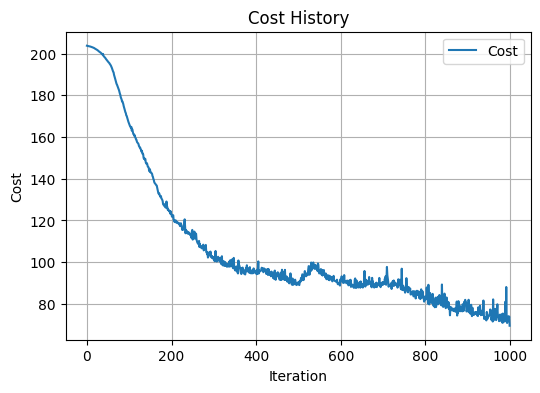

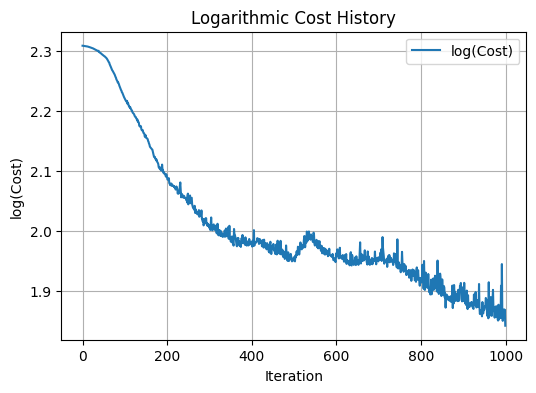

In [ ]:
# Plot cost history
plt.figure(figsize=(6,4))
plt.plot(cost_history, label="Cost")
plt.title("Cost History")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend(), plt.grid()
plt.show()

# Logarithmic cost history
plt.figure(figsize=(6,4))
plt.plot(torch.log10(torch.tensor(cost_history)), label="log(Cost)")
plt.title("Logarithmic Cost History")
plt.xlabel("Iteration")
plt.ylabel("log(Cost)")
plt.legend(), plt.grid()
plt.show()

In [11]:
ObsManager.print_parameters()

Index | Kernel Types | Noise     | hp1       | hp2        | mu                    
----------------------------------------------------------------------------------
0     | Gaussian     | 1.000e-04 | 6.015e-01 | -1.344e-03 | [0.000e+00, 0.000e+00]
1     | Gaussian     | 1.000e-04 | 7.831e-01 | 1.566e-01  | [0.000e+00, 0.000e+00]
2     | Gaussian     | 1.000e-04 | 1.868e-01 | 1.991e-01  | [0.000e+00, 0.000e+00]
3     | Gaussian     | 1.000e-04 | 2.981e-01 | -2.137e-01 | [0.000e+00, 0.000e+00]
4     | Gaussian     | 1.000e-04 | 5.257e-01 | -6.941e-04 | [0.000e+00, 0.000e+00]
5     | Gaussian     | 1.000e-04 | 5.122e-01 | -1.534e-03 | [0.000e+00, 0.000e+00]
6     | Gaussian     | 1.000e-04 | 4.032e-01 | 1.628e-01  | [0.000e+00, 0.000e+00]
7     | Gaussian     | 1.000e-04 | 5.510e-01 | 3.059e-01  | [0.000e+00, 0.000e+00]
8     | Gaussian     | 1.000e-04 | 7.183e-01 | 1.676e-01  | [0.000e+00, 0.000e+00]
9     | Gaussian     | 1.000e-04 | 6.358e-01 | -1.310e-03 | [0.000e+00, 0.000e+00]


### Post-Process Optimization Results

In [12]:
# Use Optimal Z values to Build GP Models and Optimal A and Z matrices
optimal_Z = Z.detach()
for i in range(p):
    ObsManager.train_observable(i, Xtrain, optimal_Z[:,i])  # train GP Observables with Optimal Z outputs

# ObsManager.optimize_hyperparameters(opt_mu=False, opt_sigma=True, max_iter=100)   # Optimize Kernel hyperparameters for Optimal training data
# print(f'GPO Hyperparameters have been optimized.')
ObsManager.print_parameters()

ObsList = [i for i in range(p)]
A, C = gpk.getKoopman(ObsManager, ObsList, Xall, nTrain, stateAug=False)

Index | Kernel Types | Noise     | hp1       | hp2        | mu                    
----------------------------------------------------------------------------------
0     | Gaussian     | 1.000e-04 | 6.015e-01 | -1.344e-03 | [0.000e+00, 0.000e+00]
1     | Gaussian     | 1.000e-04 | 7.831e-01 | 1.566e-01  | [0.000e+00, 0.000e+00]
2     | Gaussian     | 1.000e-04 | 1.868e-01 | 1.991e-01  | [0.000e+00, 0.000e+00]
3     | Gaussian     | 1.000e-04 | 2.981e-01 | -2.137e-01 | [0.000e+00, 0.000e+00]
4     | Gaussian     | 1.000e-04 | 5.257e-01 | -6.941e-04 | [0.000e+00, 0.000e+00]
5     | Gaussian     | 1.000e-04 | 5.122e-01 | -1.534e-03 | [0.000e+00, 0.000e+00]
6     | Gaussian     | 1.000e-04 | 4.032e-01 | 1.628e-01  | [0.000e+00, 0.000e+00]
7     | Gaussian     | 1.000e-04 | 5.510e-01 | 3.059e-01  | [0.000e+00, 0.000e+00]
8     | Gaussian     | 1.000e-04 | 7.183e-01 | 1.676e-01  | [0.000e+00, 0.000e+00]
9     | Gaussian     | 1.000e-04 | 6.358e-01 | -1.310e-03 | [0.000e+00, 0.000e+00]


# Simulation and Validation

## Model Simulation

In [14]:
A, C = A.to(device='cpu'), C.to(device='cpu')
SimData = SimData.to(device='cpu')
ICsetTrain, ICsetTest = ICsetTrain.to(device='cpu'), ICsetTest.to(device='cpu')
# Evaluation on training set
ZmeanTrain = torch.empty((nTrain, p, N))    # n+p for state-augmentation
ZcvTrain = torch.empty((nTrain, p, p, N))   # n for no state-augmentation
#ZmeanTrain[:, :n, 0] = ICsetTrain.T    # only for state-augmentation

XhatTrain = torch.empty((nTrain, n, N))
XcvhatTrain = torch.empty((nTrain, n, n, N))
TrainRMSE = torch.empty((nTrain,n))

for j in range(nTrain): # GP Predict for all training trajectories
    for i in range(p):  # GP predict IC and IC-cv
        ZmeanTrain[j, i, 0] = ObsManager.predict_mean(i, ICsetTrain[:, j].view(n,1))        # n+i for state-augmentation
        ZcvTrain[j, i, i, 0] = ObsManager.predict_covariance(i, ICsetTrain[:, j].view(n,1)) # n for no state-augmentation
    
    ZmeanTrain[j, :, :], ZcvTrain[j, :, :, :], XhatTrain[j, :, :], XcvhatTrain[j, :, :, :] = gpk.sim_LTI(ZmeanTrain[j,:,0], A, C, num_steps=N, ts=None, x0cv=ZcvTrain[j,:,:,0])
    TrainRMSE[j,:] = torch.sqrt(torch.mean((XhatTrain[j,:,:] - SimData[j,:,:N])**2,1))

# Evaluation on test set
ZmeanTest = torch.empty((nTest, p, N))
ZcvTest = torch.empty((nTest, p, p, N))
#ZmeanTest[:, :n, 0] = ICsetTest.T  # only for state-augmentation

XhatTest = torch.empty((nTest, n, N))
XcvhatTest = torch.empty((nTest, n, n, N))
TestRMSE = torch.empty((nTest,n))

for j in range(nTest): # GP Predict for all testing trajectories
    for i in range(p):  # GP predict IC and IC-cv
        ZmeanTest[j, i, 0] = ObsManager.predict_mean(i, ICsetTest[:, j].view(n,1))          # n+i for state-augmentation
        ZcvTest[j, i, i, 0] = ObsManager.predict_covariance(i, ICsetTest[:, j].view(n,1))   # n for no state-augmentation

    ZmeanTest[j, :, :], ZcvTest[j, :, :, :], XhatTest[j, :, :], XcvhatTest[j, :, :, :] = gpk.sim_LTI(ZmeanTest[j,:,0], A, C, num_steps=N, ts=None, x0cv=ZcvTest[j,:,:,0])
    TestRMSE[j,:] = torch.sqrt(torch.mean((XhatTest[j,:,:] - SimData[nTest+j,:,:N])**2,1))

XhatTrain, XhatTest, XcvhatTrain, XcvhatTest = XhatTrain.detach(), XhatTest.detach(), XcvhatTrain.detach(), XcvhatTest.detach()
TestRMSE, TrainRMSE = TestRMSE.detach(), TrainRMSE.detach()

In [ ]:
# Function to compute RMSE, NLPD, and sRMSE


time = torch.arange(0., ts * N, ts)
idx1, idx2, idx3 = torch.argmin(TrainRMSE.mean(dim=1)), torch.argmin(TestRMSE.mean(dim=1)), torch.argmax(TestRMSE.mean(dim=1))

## Trajectory and Time-Evolution Plots

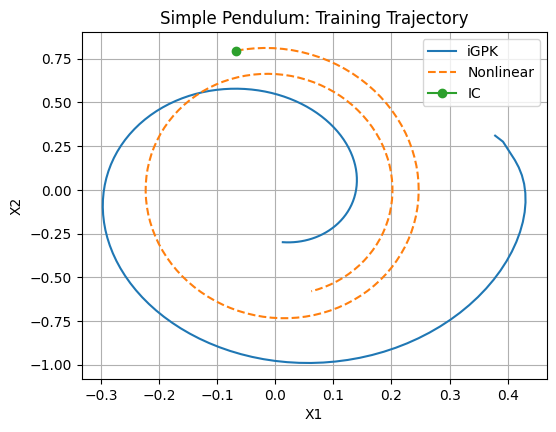

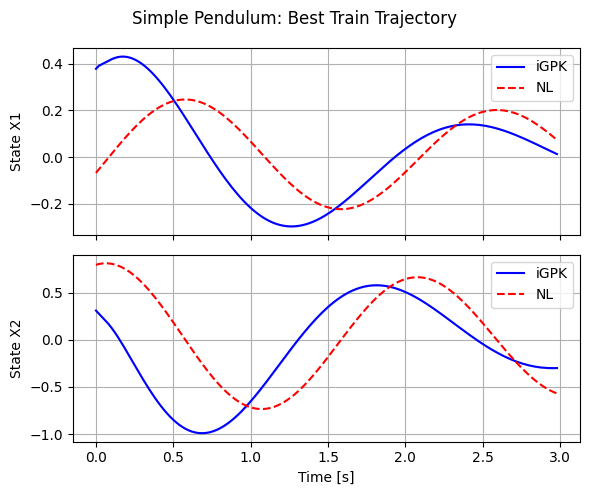

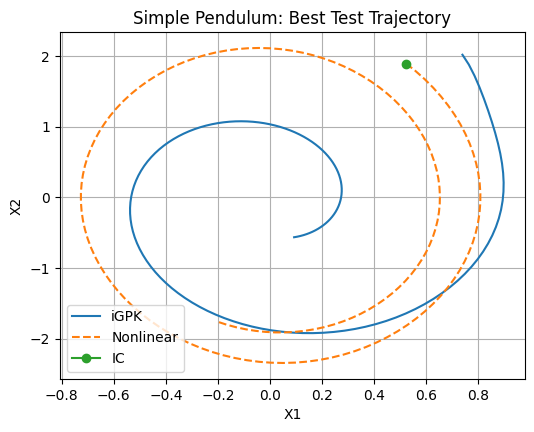

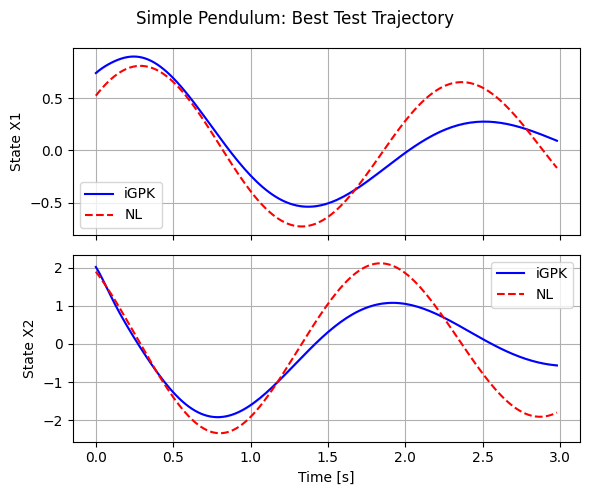

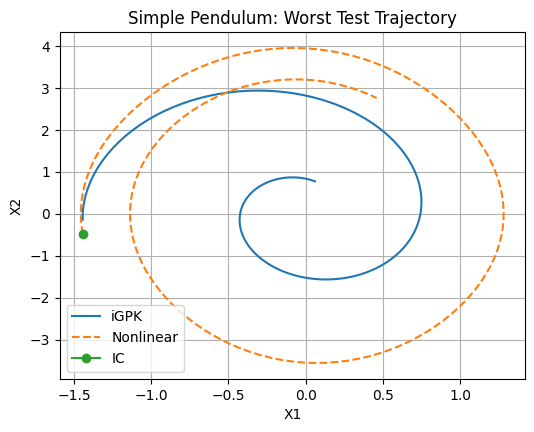

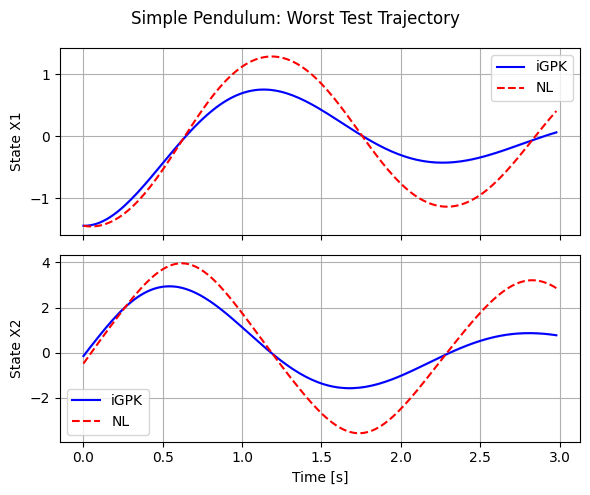

In [ ]:
gpk.plot_phase(XhatTrain, SimData, ICsetTrain, idx1, N, system_name, 'Training Trajectory')
gpk.plot_time_series_with_bounds(time, XhatTrain, XcvhatTrain, SimData, idx1, N, system_name, title_suffix='Best Train Trajectory')

gpk.plot_phase(XhatTest, SimData, ICsetTest, idx2, N, system_name, 'Best Test Trajectory', sim_offset=nTrain)
gpk.plot_time_series_with_bounds(time, XhatTest, XcvhatTest, SimData, idx2, N, system_name, title_suffix='Best Test Trajectory', sim_offset=nTrain)

gpk.plot_phase(XhatTest, SimData, ICsetTest, idx3, N, system_name, 'Worst Test Trajectory', sim_offset=nTrain)
gpk.plot_time_series_with_bounds(time, XhatTest, XcvhatTest, SimData, idx3, N, system_name, title_suffix='Worst Test Trajectory', sim_offset=nTrain)

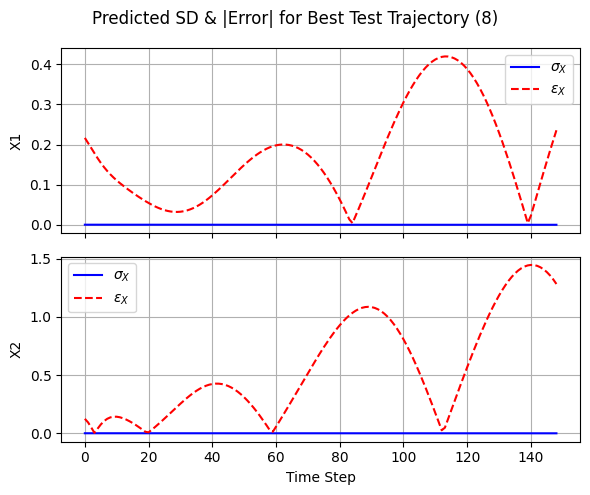

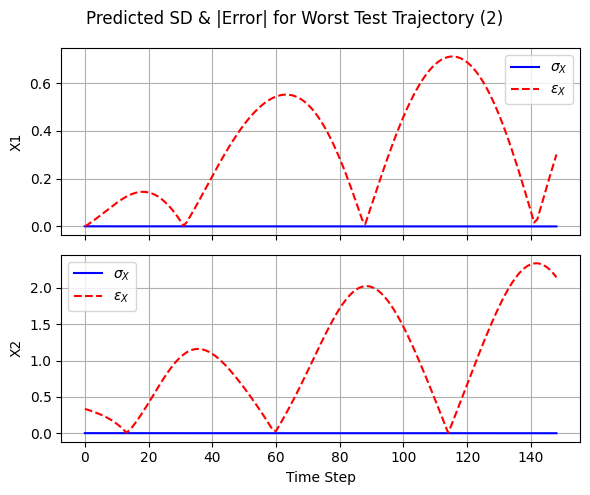

In [17]:
# For best test trajectory (e.g., idx2)
gpk.plot_predicted_sd_error(XcvhatTest, SimData, XhatTest, idx=idx2, N=N, nTrain=nTrain, trajectory_label="Best Test")

# For worst test trajectory (e.g., idx3)
gpk.plot_predicted_sd_error(XcvhatTest, SimData, XhatTest, idx=idx3, N=N, nTrain=nTrain, trajectory_label="Worst Test")

## System-level Plots

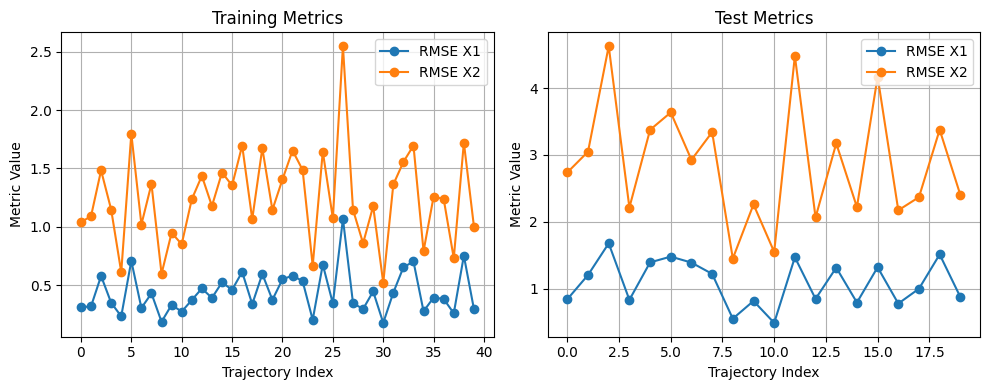

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Training set plot
axes[0].plot(range(nTrain), TrainRMSE[:,0].numpy(), marker='o', linestyle='-', label='RMSE X1')
axes[0].plot(range(nTrain), TrainRMSE[:,1].numpy(), marker='o', linestyle='-', label='RMSE X2')
axes[0].set_title('Training Metrics')
axes[0].set_xlabel("Trajectory Index")
axes[0].set_ylabel("Metric Value")
axes[0].legend()
axes[0].grid()

# Test set plot
axes[1].plot(range(nTest), TestRMSE[:,0].numpy(), marker='o', linestyle='-', label='RMSE X1')
axes[1].plot(range(nTest), TestRMSE[:,1].numpy(), marker='o', linestyle='-', label='RMSE X2')
axes[1].set_title('Test Metrics')
axes[1].set_xlabel("Trajectory Index")
axes[1].set_ylabel("Metric Value")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

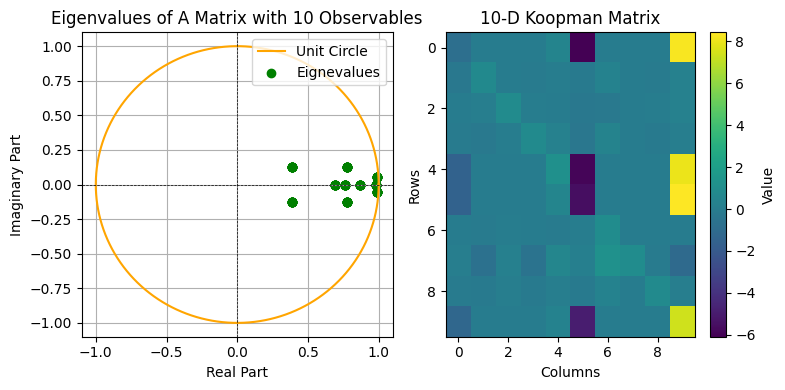

In [23]:
# Eigen value plot of Koopman Matrices
eigval = torch.linalg.eigvals(A)

eigreal, eigimag = eigval.real, eigval.imag
eigreal, eigimag = eigreal.detach().numpy(), eigimag.detach().numpy()
eig_mag = np.sqrt(eigreal**2 + eigimag**2)

theta = np.linspace(0, 2*np.pi, 500)
unitCirclex, unitCircley = np.cos(theta), np.sin(theta)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
# First subplot: Eigenvalues plot
axes[0].plot(unitCirclex, unitCircley, color='orange', label='Unit Circle')
for i in range(np.size(eig_mag)):
    if eig_mag[i] <= 1:
        axes[0].scatter(eigreal, eigimag, color='green', label='Eigenvalues')
    else:
        axes[0].scatter(eigreal, eigimag, color='red', label='Eigenvalues')

axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].axvline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].set_title(f"Eigenvalues of A Matrix with {p} Observables")
axes[0].set_xlabel("Real Part")
axes[0].set_ylabel("Imaginary Part")
axes[0].grid(True)
axes[0].legend(labels=['Unit Circle', 'Eignevalues'], loc='upper right')

# Second subplot: Heatmap of matrix A
im = axes[1].imshow(A.detach().numpy(), cmap='viridis', aspect='auto')
fig.colorbar(im, ax=axes[1], label="Value")
axes[1].set_title(f'{A.shape[0]}-D Koopman Matrix')
axes[1].set_xlabel("Columns")
axes[1].set_ylabel("Rows")
plt.tight_layout()
plt.show()

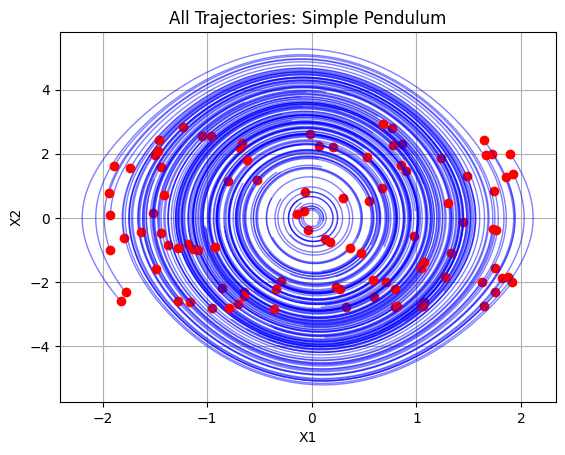

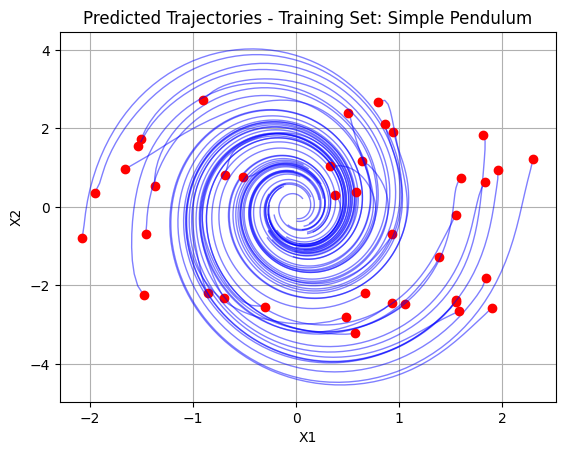

In [ ]:
# Phase Diagram from all IC simulation
if SimData.shape[1] == 3:       # 3D plot
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    for j in range(SimData.shape[0]):
        ax.plot(SimData[j, 0, :], SimData[j, 1, :], SimData[j, 2, :],
                alpha=0.5, color='blue')
        ax.scatter(SimData[j, 0, 0], SimData[j, 1, 0], SimData[j, 2, 0],
                   color='red')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title(f'All Trajectories: {system_name}')
    ax.grid(True)
    plt.show()

elif SimData.shape[1] == 2:     # 2D plot
    for j in range(SimData.shape[0]):
        plt.plot(SimData[j, 0, :], SimData[j, 1, :],
                 alpha=0.5, color='blue', linewidth=1.)
        plt.plot(SimData[j, 0, 0], SimData[j, 1, 0],
                 'o', color='red')
    plt.grid()
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title(f'All Trajectories: {system_name}')
    plt.show()

elif SimData.shape[1] == 1:     # 1D plot
    for j in range(SimData.shape[0]):
        plt.plot(SimData[j, 0, :], alpha=0.5, color='blue', linewidth=1.)
        plt.plot(SimData[j, 0, 0], 'o', color='red')
    plt.grid()
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title(f'All Trajectories: {system_name}')
    plt.show()

else:   # system dimension > 3
    print('IC Phase Plots supported for 1/2/3-D systems only.')


# Training Set Predicted Trajectories
if XhatTrain.shape[1] == 3: # 3D plot
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    for j in range(XhatTrain.shape[0]):
        ax.plot(XhatTrain[j, 0, :], XhatTrain[j, 1, :], XhatTrain[j, 2, :],
                alpha=0.5, color='blue')
        ax.scatter(XhatTrain[j, 0, 0], XhatTrain[j, 1, 0], XhatTrain[j, 2, 0],
                   color='red')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title(f'Predicted Trajectories - Training Set: {system_name}')
    ax.grid(True)
    plt.show()

elif XhatTrain.shape[1] == 2:   # 2D plot
    for j in range(XhatTrain.shape[0]):
        plt.plot(XhatTrain[j, 0, :], XhatTrain[j, 1, :],
                 alpha=0.5, color='blue', linewidth=1.)
        plt.plot(XhatTrain[j, 0, 0], XhatTrain[j, 1, 0],
                 'o', color='red')
    plt.grid()
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title(f'Predicted Trajectories - Training Set: {system_name}')
    plt.show()

else:
    print('Trianing Response Phase PLots supported for 2/3-D systems only.')

# Model Saving

In [21]:
today = datetime.date.today()

iGPKResults = {
    "Sysem Name": system_name,
    "Data": SimData,
    "Train Test Factors": [nTrain, nTest],
    "Initial Conditions": [ICsetTrain, ICsetTest],
    "ObsManager": ObsManager,
    "Observables": ObsManager.observables,
    "Koopman A": A,
    "Koopman C": C,
    "X Train": Xtrain,
    "Optimal Z": optimal_Z,
    "Train RMSE": TrainRMSE,
    "Test RMSE": TestRMSE,
    "Adam Options": [learn_rate, max_iter, lambda1, lambda2, lambda3]
}

# torch.save(iGPKResults, f'Results/iGPKAuto_{system_name}_Noisy_{today}.pt')